# Логистическая регрессия

 Ранее мы решали задачу регрессии. В этом блокноте речь пойдет о **задаче классификации**. В таких задачах алгоритм должен уметь относить объекты к тому или иному классу.

## 1. Бинарная классификация

Простейший случай - **бинарная классификация**, когда у нас есть только два класса. Целевая переменная `y` принимает два значения: 0 или 1 (-1 или +1). Например, письмо со спамом будет относиться к классу 1, обычное письмо - к классу 0. Посмотрим на рисунке графическое представление задачи классификации.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})

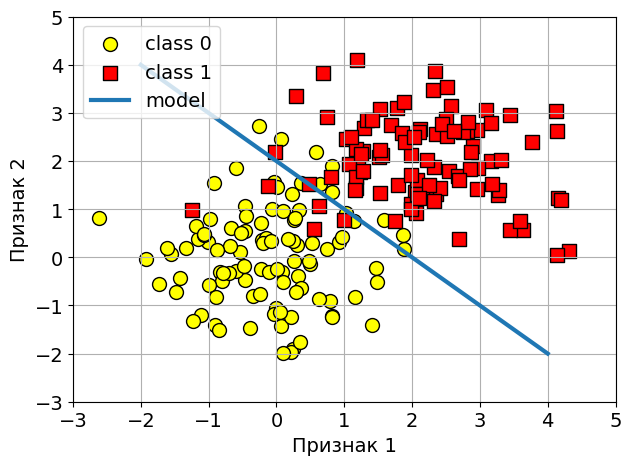

In [ ]:
# сгенерируем объекты нулевого класса с двумя признаками
np.random.seed(42)
X_data = np.random.randn(100, 2)
y_labels = np.zeros(100)
# добавим класс 1
X_data = np.r_[X_data, 2.0 + np.random.randn(100, 2)]
y_labels = np.r_[y_labels, np.ones(100)]
# изобразим данные на графике
plt.rcParams['figure.figsize'] = (7, 5)
plt.scatter(X_data[:100, 0], X_data[:100, 1], c='yellow', s=100, marker='o',
            edgecolors='black', label='class 0')
plt.scatter(X_data[100:, 0], X_data[100:, 1], c='red', s=100, marker='s',
            edgecolors='black', label='class 1')
plt.plot([-2, 4], [4, -2], linewidth=3, label='model')
plt.xlim([-3, 5])
plt.ylim([-3, 5])
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid();

Задачу регрессии мы решали, обучая линейную модель. В задачах классификации линейные модели тоже используются. Разберемся, каким образом.

Уравнение линейной регрессии:

$$\hat y=\sum^n_{i=1}\sum^m_{j=0}x_{ij}w_j=Xw$$

Проблемы:

1) нам нужны прогнозы либо 1 или 0 (метка класса), либо число из диапазона [0, 1] (вероятность отнесения объекта к 1-му классу), но
`np.dot(X, w) = [-12, 2, 1.5, 0.0005, 1000 ...]` - любое вещественное число;  
2) MSE, как функция потерь, не подходит.


Используем вместо вероятности `p=[0, 1]` шансы: $$odds = \frac{p_1}{1 - p_1} = \frac{p_1}{p_0}$$

In [ ]:
p = 1 - 0.99999
p / (1 - p)

1.0000100000954499e-05

Возьмем логарифм шансов:
$$\ln(odds)=\ln\Big(\frac{p_1}{1-p_1}\Big)$$

In [ ]:
p = 0.0000001
print(np.log(p / (1 - p)))

-16.118095550958316


Логарифм шансов принимает любое значение от $-\inf$ до $+\inf$, значит его можно использовать в уравнении линейной регрессии.

$$X{w} = \ln\Big(\frac{{p}}{1 - {p}}\Big)$$
$$\exp(X{w}) = \frac{{p}}{1 - {p}}$$
$$(1-{p})\exp(X{w}) = {p}$$
$$\exp(X{w})-{p}\exp(X{w}) = {p}$$
$$\exp(X{w})={p}(1+\exp(X{w}))$$
$${p}=\frac{\exp{(X{w})}}{1+\exp{(X{w})}}$$
$${p}=\frac{1}{1+\exp{(-X{w})}}=\sigma(X {w}),$$

где $\sigma$ - сигмоида. Напишем функцию для ее расчета.

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

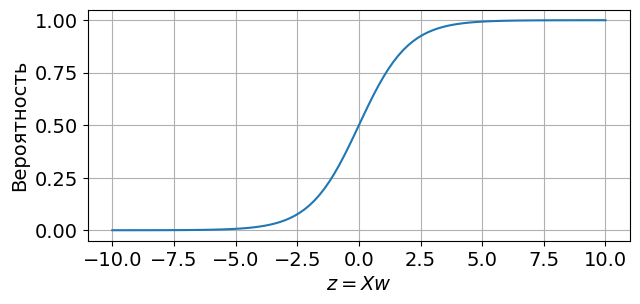

In [ ]:
# построим график сигмоиды
plt.figure(figsize = (7, 3))
z = np.linspace(-10, 10, 101)
probabilities = sigmoid(z)
plt.plot(z, probabilities)
plt.xlabel('$z=Xw$')
plt.ylabel('Вероятность')
plt.grid();

### Логистическая функция потерь

Согласно распределению Бернулли, вероятность встретить объект с классом $y_i$ равна $$p_i^{y_i}(1-p_i)^{1-y_i}$$

$\text{Likelihood (правдоподобие):}$
$$L(X)=\prod_{i=1}^{n}{p_i^{y_i}(1-p_i)^{1-y_i}}\rightarrow max$$
$$\ln L(X)=\sum_{i=1}^{n}\big ({\ln{p_i}^{y_i}+\ln(1-p_i)^{1-y_i}}\big)$$
$$\ln (-L(X))=\sum_{i=1}^{n}\big({-y_i\ln{p_i}-(1-y_i)\ln(1-p_i)\big)}$$
$$LogLoss=\frac{1}{n}\sum_{i=1}^{n}\big({-y_i\ln{p_i}-(1-y_i)\ln(1-p_i)\big)}\rightarrow min$$

$y=0/1$ - истинный класс   
$p=[0,1]$ - ответ алгоритма (вероятность, с которой алгоритм относит объект к 1-му классу)

Напишем функцию для расчета логлосса.

In [ ]:
def logloss(y, p):
    err = np.mean(- y * np.log(p) - (1.0 - y) * np.log(1.0 - p))
    return err

In [ ]:
# Пример применения
print(logloss(y=1, p=0.00000001))

18.420680743952367


In [ ]:
logloss(y=0, p=0)

<ipython-input-7-349f61fef2f2>:2: RuntimeWarning: divide by zero encountered in log
  err = np.mean(- y * np.log(p) - (1.0 - y) * np.log(1.0 - p))
<ipython-input-7-349f61fef2f2>:2: RuntimeWarning: invalid value encountered in scalar multiply
  err = np.mean(- y * np.log(p) - (1.0 - y) * np.log(1.0 - p))


nan

Найдем производную от функции потерь:

$${LogLoss}=\frac{1}{n}\sum_{i=1}^{n}\big({-y_i\ln{p_i}-(1-y_i)\ln(1-p_i)\big)}$$
Обозначим ${p_i}=\sigma({x_iw})=\frac{1}{1+\text{exp}(-x_iw)}$
$$\frac{\mathrm d}{\mathrm dw}{LogLoss}=\frac{\mathrm d}{\mathrm dw}\Big(-\frac{1}{n}\sum_{i=1}^{n}\big(y_i\ln\sigma(x_iw)+(1-y_i)\ln(1-\sigma(x_iw))\big)\Big)=$$
$$=-\frac{1}{n}\sum_{i=1}^{n}\big(y_i\frac{\mathrm d}{\mathrm dw}\ln\sigma(x_iw)+(1-y_i)\frac{\mathrm d}{\mathrm dw}\ln(1-\sigma(x_iw))\big)=$$
$$=-\frac{1}{n}\sum_{i=1}^{n}\big(y_i\frac{\frac{\mathrm d}{\mathrm dw}\sigma(x_iw)}{\sigma(x_iw)}+(1-y_i)\frac{\frac{\mathrm d}{\mathrm dw}(1-\sigma(x_iw))}{1-\sigma(x_iw)}\big)$$
Используя выражение для производной сигмоидной функции (вывод см. после ДЗ): $\frac{\mathrm d\sigma(z)}{\mathrm dz}=\sigma(z)(1-\sigma(z))$, получим:
$$\frac{\mathrm d}{\mathrm dw}{LogLoss}=-\frac{1}{n}\sum_{i=1}^{n}\big(y_i\frac{\sigma(x_iw)(1-\sigma(x_iw))x_i}{\sigma(x_iw)}+(1-y_i)\frac{-\sigma(x_iw)(1-\sigma(x_iw))x_i}{1-\sigma(x_iw)}\big)=$$
$$=-\frac{1}{n}\sum_{i=1}^{n}\big(y_i{(1-\sigma(x_iw))x_i}-(1-y_i){\sigma(x_iw)x_i}\big)=$$
$$=-\frac{1}{n}\sum_{i=1}^{n}\big(y_i-y_i\sigma(x_iw)-\sigma(x_iw)+y_i\sigma(x_iw)\big)x_i=$$
$$=\frac{1}{n}\sum_{i=1}^{n}\big(\sigma(x_iw)-y_i\big)x_i=\frac{1}{n}\sum_{i=1}^{n}\big(p_i-y_i\big)x_i$$
В векторной форме:
$$\frac{\mathrm d}{\mathrm d{w}}{LogLoss}=\frac{1}{n}({p}-{y})X$$
Тогда корректировка весов в методе градиентного спуска будет выполняться по формуле:
$${w}={w}-\eta \frac{1}{n}({p}-{y})X$$

### Пример

In [ ]:
X = np.array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],     # для умножения на intercept
              [10, 5, 3, 2, 0, 9, 1, 0, 8, 2],    # количество прогулов
              [150, 160, 170, 175, 180, 130, 200, 230, 160, 180], # балл ЕГЭ
              [1000, 1500, 2000, 2000, 2500, 1000, 3000, 3500, 1500, 2000] # баллы за предыдущие экзамены
             ], dtype = np.float64).T
y = np.array([1, 1, 1, 1, 0, 1, 0, 0, 1, 0])      # сдаст (0) или не сдаст (1) экзамен по БД

In [ ]:
X

array([[1.00e+00, 1.00e+01, 1.50e+02, 1.00e+03],
       [1.00e+00, 5.00e+00, 1.60e+02, 1.50e+03],
       [1.00e+00, 3.00e+00, 1.70e+02, 2.00e+03],
       [1.00e+00, 2.00e+00, 1.75e+02, 2.00e+03],
       [1.00e+00, 0.00e+00, 1.80e+02, 2.50e+03],
       [1.00e+00, 9.00e+00, 1.30e+02, 1.00e+03],
       [1.00e+00, 1.00e+00, 2.00e+02, 3.00e+03],
       [1.00e+00, 0.00e+00, 2.30e+02, 3.50e+03],
       [1.00e+00, 8.00e+00, 1.60e+02, 1.50e+03],
       [1.00e+00, 2.00e+00, 1.80e+02, 2.00e+03]])

In [ ]:
def standardization(X):
    S = (X - X.mean(axis=0)) / X.std(axis=0)
    return S

X_st = X.copy()
X_st[:, 1:] = standardization(X[:, 1:])
X_st

array([[ 1.        ,  1.67705098, -0.90101825, -1.29099445],
       [ 1.        ,  0.2795085 , -0.51760623, -0.64549722],
       [ 1.        , -0.2795085 , -0.13419421,  0.        ],
       [ 1.        , -0.55901699,  0.0575118 ,  0.        ],
       [ 1.        , -1.11803399,  0.24921781,  0.64549722],
       [ 1.        ,  1.39754249, -1.66784229, -1.29099445],
       [ 1.        , -0.83852549,  1.01604185,  1.29099445],
       [ 1.        , -1.11803399,  2.16627792,  1.93649167],
       [ 1.        ,  1.11803399, -0.51760623, -0.64549722],
       [ 1.        , -0.55901699,  0.24921781,  0.        ]])

In [ ]:
# логистическая регрессия с использованием градиентного спуска
def LogReg(X, y, iterations, eta=1e-4, verbose=True):
    np.random.seed(42)
    n = X.shape[0]                  # число наблюдений
    m = X.shape[1]                  # число признаков
    w = np.random.randn(m)          # начальное приближение весов
    weights = [w.copy()]
    error_pre = logloss(y, sigmoid(np.dot(X, w))) # начальная ошибка
    errors = [error_pre]
    if verbose: print(f'0: weights={w}, LogLoss={error_pre:.3f}')
    for i in range(1, iterations + 1):
        z = np.dot(X, w) # log(p/(1-p))
        p = sigmoid(z) # p [0, 1]
        grad = 1/n * np.dot((p - y), X)
        w -= eta * grad
        weights.append(w.copy())
        error = logloss(y, sigmoid(np.dot(X, w)))
        errors.append(error)
        if verbose and (i % (iterations / 10) == 0):
            print(f'{i}: weights={w}, LogLoss={error:.3f}')
    return weights, errors

In [ ]:
w_list, err_list = LogReg(X_st, y, iterations=100, eta=0.05)

0: weights=[ 0.49671415 -0.1382643   0.64768854  1.52302986], LogLoss=1.999
10: weights=[0.51648177 0.18161531 0.3284174  1.18760302], LogLoss=1.367
20: weights=[0.51828501 0.44291447 0.05537687 0.90230483], LogLoss=0.922
30: weights=[ 0.50833007  0.63781241 -0.15774919  0.67958696], LogLoss=0.658
40: weights=[ 0.49945746  0.77880816 -0.31607465  0.51304993], LogLoss=0.513
50: weights=[ 0.49708411  0.8828792  -0.434224    0.38758735], LogLoss=0.433
60: weights=[ 0.50081758  0.962895   -0.52578231  0.28953151], LogLoss=0.384
70: weights=[ 0.50903666  1.02694342 -0.59986725  0.20972213], LogLoss=0.352
80: weights=[ 0.52036947  1.07992683 -0.66205585  0.14251392], LogLoss=0.330
90: weights=[ 0.53384281  1.1249002  -0.7157803   0.0843959 ], LogLoss=0.313
100: weights=[ 0.54878456  1.16385425 -0.76323302  0.03310005], LogLoss=0.300


In [ ]:
w = w_list[-1]               # найденные веса
p = sigmoid(np.dot(X_st, w)) #
print('prob =', p.round(2))  # рассчитанные вероятности
print('true =', y)           # истинный класс
print('pred =', np.where(p > 0.5, 1, 0)) # предсказанный класс

prob = [0.96 0.78 0.58 0.46 0.28 0.97 0.24 0.09 0.9  0.43]
true = [1 1 1 1 0 1 0 0 1 0]
pred = [1 1 1 0 0 1 0 0 1 0]


Визуализируем разделяющую поверхность.

In [ ]:
dots_x = [X_st[:, 1].min(), X_st[:, 1].max()]
dots_y = [X_st[:, 2].min(), X_st[:, 2].max()]
x_, y_ = np.meshgrid(dots_x, dots_y)
z_ = (-w[0] - w[1] * x_ - w[2] * y_) / w[3]

In [ ]:
import plotly.graph_objects as go
import plotly.express as px

fig = go.Figure(data=[go.Scatter3d(
        x=X_st[:, 1],
        y=X_st[:, 2],
        z=X_st[:, 3],
        mode='markers',
        marker=dict(
          size=7,
          color=y,
          colorscale='Viridis',   # choose a colorscale
          opacity=1,
          line=dict(width=2, color='Black'))
)])
fig.add_trace(go.Surface(z=z_, x=x_, y=y_, surfacecolor=(0,0,0),
                         opacity=.7, showscale=False))
fig.update_layout(autosize=False,
                  width=500, height=500,
                  margin=dict(l=5, r=5, b=5, t=5))
fig.show()

### LogisticRegression - логистическая регрессия из библиотеки sklearn

In [ ]:
from sklearn.linear_model import LogisticRegression

LogisticRegression().get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

Параметры модели LogisticRegression:

- `penalty` - тип регуляризации (по умолчанию `l2`), Другие варианты: `l1`, `elasticnet` и `none`;  
- `C` - положительное число с плавающей запятой (1.0 по умолчанию), которое определяет относительную силу регуляризации. Меньшие значения указывают на более сильную регуляризацию;  
- `fit_intercept` - логическое значение (по умолчанию True), которое решает, следует ли вычислять интерсепт (True) или считать его равным нулю (False);  
- `class_weight` - словарь, `balanced` или `None` (по умолчанию), определяет веса, относящиеся к каждому классу. Когда указано значение `None`, все классы имеют равный вес;  
- `solver` - строка (по умолчанию `liblinear`), которая решает, какой решатель использовать для подбора модели. Есть варианты: `newton-cg`, `lbfgs`, `sag` и `saga`;
- `max_iter` - целое число (по умолчанию 100), определяющее максимальное количество итераций;
- `multi_class` - строка (по умолчанию `auto`), которая определяет количество классов. Другие варианты - `multinomial` и `ovr`;


In [ ]:
model = LogisticRegression(solver='liblinear',
                           penalty='l2',
                           C=1,
                           fit_intercept=False,
                           random_state=42)
model.fit(X_st, y)
pred = model.predict(X_st)       # предсказанные классы
prob = model.predict_proba(X_st) # вероятности

In [ ]:
print('prob =', prob[:, 1].round(2))
print('true =', y)
print('pred =', pred)

prob = [0.96 0.8  0.58 0.5  0.27 0.97 0.14 0.04 0.88 0.47]
true = [1 1 1 1 0 1 0 0 1 0]
pred = [1 1 1 0 0 1 0 0 1 0]


Точность модели оценивается по метрике **accuracy** - доля правильно предсказанных классов.

In [ ]:
model.score(X_st, y)

0.9

In [ ]:
model.coef_

array([[ 0.39889297,  0.64373469, -0.69608062, -0.73759326]])

### SGDClassifier - логистическая регрессия, использующая стохастический градиентный спуск

Класс SGDClassifier реализует простую процедуру обучения стохастическим градиентным спуском, которая поддерживает различные функции потерь и штрафы за классификацию.

In [ ]:
from sklearn.linear_model import SGDClassifier

SGDClassifier().get_params()

{'alpha': 0.0001,
 'average': False,
 'class_weight': None,
 'early_stopping': False,
 'epsilon': 0.1,
 'eta0': 0.0,
 'fit_intercept': True,
 'l1_ratio': 0.15,
 'learning_rate': 'optimal',
 'loss': 'hinge',
 'max_iter': 1000,
 'n_iter_no_change': 5,
 'n_jobs': None,
 'penalty': 'l2',
 'power_t': 0.5,
 'random_state': None,
 'shuffle': True,
 'tol': 0.001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [ ]:
model_sgd = SGDClassifier(loss='log_loss', # logloss
                         learning_rate='constant',
                         eta0=0.1,
                         max_iter=50,
                         alpha=0,
                         fit_intercept=False,
                         tol=None,
                         shuffle=False,
                         random_state=42)
model_sgd.fit(X_st, y)
pred = model_sgd.predict(X_st)       # предсказанные классы
prob = model_sgd.predict_proba(X_st) # вероятности

In [ ]:
model_sgd.coef_

array([[ 1.24584705,  1.58421817, -1.96107359, -1.80641135]])

In [ ]:
print('prob =', prob[:, 1].round(2))
print('true =', y)
print('pred =', pred)

prob = [1.   0.98 0.74 0.56 0.1  1.   0.01 0.   0.99 0.47]
true = [1 1 1 1 0 1 0 0 1 0]
pred = [1 1 1 1 0 1 0 0 1 0]


In [ ]:
(y == pred).mean()

1.0

In [ ]:
model_sgd.score(X_st, y)

1.0

## Источники

[LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

[SGDClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html)

## Задания

1. Исправить функцию `logloss` (на случай `p=0` или `p=1`). (2 балла)
2. Построить зависимости логлосса от числа итераций для данных с занятия при разной скорости обучения (не менее трех значений `eta`, на одном графике). (3 балла)
3. Написать функцию, которая рассчитывает метрику *accuracy* (доля правильно предсказанных классов). Функция должна принимать массив истинных классов, массив рассчитанных вероятностей и порог вероятности. (3 балла)
4. Сгенерировать датасет при помощи `sklearn.datasets.make_classification`. Обучить `SGDClassifier` и собственную логистическую регрессию (функция `LogReg`). Сравнить точность моделей по метрике *accuracy*. (4 балла)

In [ ]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000,
                           n_features=5,
                           n_classes=2,
                           n_clusters_per_class=2,
                           random_state=42)

In [ ]:
#

## Дополнительный материал

Производная сигмоидной функции:
$$\frac{\mathrm d\sigma(z)}{\mathrm dz}=\frac{\mathrm d}{\mathrm dz}\Big(\frac{1}{1+\exp(-z)}\Big)=-(1+\exp(-z))^{-2}\frac{\mathrm d}{\mathrm dz}\Big(1+\exp(-z)\Big)=$$
$$=-(1+\exp(-z))^{-2}(0+\frac{\mathrm d}{\mathrm dz}\exp(-z))=-(1+\exp(-z))^{-2}(\exp(-z)\frac{\mathrm d}{\mathrm dz}(-z))=$$
$$=(1+\exp(-z))^{-2}\exp(-z)=\frac{\exp(-z)}{(1+\exp(-z))^{2}}=\frac{1}{1+\exp(-z)}\frac{\exp(-z)}{1+\exp(-z)}=$$
$$=\frac{1}{1+\exp(-z)}\frac{\exp(-z)+1-1}{1+\exp(-z)}=\frac{1}{1+\exp(-z)}\Big(1-\frac{1}{1+\exp(-z)}\Big)=\sigma(z)(1-\sigma(z))$$

In [ ]:
#